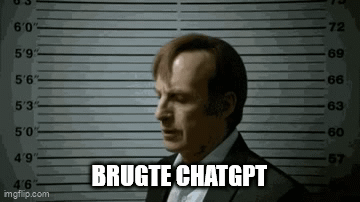

In [1]:
# This code is old

# from ucimlrepo import fetch_ucirepo
# import pandas as pd
# from IPython.display import display

# # fetch dataset
# heart_disease = fetch_ucirepo(id=45)

# display(heart_disease.data.features.head())
# display(heart_disease.data.targets.head())

# heart_disease.data.features.to_csv("./dataset.csv")

# # data (as pandas dataframes)
# X = heart_disease.data.features
# y = heart_disease.data.targets

# # # metadata
# # print(heart_disease.metadata)

# # # variable information
# # print(heart_disease.variables)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [3]:
import pandas as pd

df = pd.read_csv("processed.cleveland.data")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# columns = list(df.keys())
# n = len(columns)

# fig, axes = plt.subplots(n, n, figsize=(12*3, 12*3))
# fig.suptitle("Scatter Plots Grid", fontsize=14)

# for i, x in enumerate(columns):
#     for j, y in enumerate(reversed(columns)):
#         ax = axes[i, j]
#         ax.scatter(df[x], df[y], alpha=0.5)
#         ax.set_xlabel(x)
#         ax.set_ylabel(y)
#         ax.grid(True)

# plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.show()


In [5]:
print(df["ca"].unique())
print(df["thal"].unique())

for j, observation in enumerate(df["ca"]):
    if not observation in {"0.0", "1.0", "2.0", "3.0"}:
        print(f"Unexpected value at (ca, {j}, found: {observation})")

for j, observation in enumerate(df["thal"]):
    if not observation in {"3.0", "6.0", "7.0"}:
        print(f"Unexpected value at (thal, {j}, found: {observation})")

['0.0' '3.0' '2.0' '1.0' '?']
['6.0' '3.0' '7.0' '?']
Unexpected value at (ca, 166, found: ?)
Unexpected value at (ca, 192, found: ?)
Unexpected value at (ca, 287, found: ?)
Unexpected value at (ca, 302, found: ?)
Unexpected value at (thal, 87, found: ?)
Unexpected value at (thal, 266, found: ?)


In [6]:
print(np.unique(df["ca"], return_counts=True)) # Most occured value for ca is 0.0
print(np.unique(df["thal"], return_counts=True)) # Most occured value for thal is 7.0

(array(['0.0', '1.0', '2.0', '3.0', '?'], dtype=object), array([176,  65,  38,  20,   4], dtype=int64))
(array(['3.0', '6.0', '7.0', '?'], dtype=object), array([166,  18, 117,   2], dtype=int64))


In [ ]:
df_corrected = df.copy()
df_corrected["ca"] = df_corrected["ca"].replace("?", "0.0")         # Replace errors with 0.0
df_corrected["thal"] = df_corrected["thal"].replace("?", "0.0")     # Replace errors with 7.0

# To float datatype
for col in df_corrected:
    df_corrected[col] = pd.to_numeric(df_corrected[col], errors='coerce') 

df_corrected.to_csv("null-corrected.csv")

# QQ-plots

In [29]:
def qqPlot(series: pd.Series, title: str): 
    # Normal QQ-plot of the residuals
    sm.qqplot(series, line='q')
    plt.ylabel("Residuals")
    plt.xlabel("Z-scores")
    plt.title(title)
    plt.show()

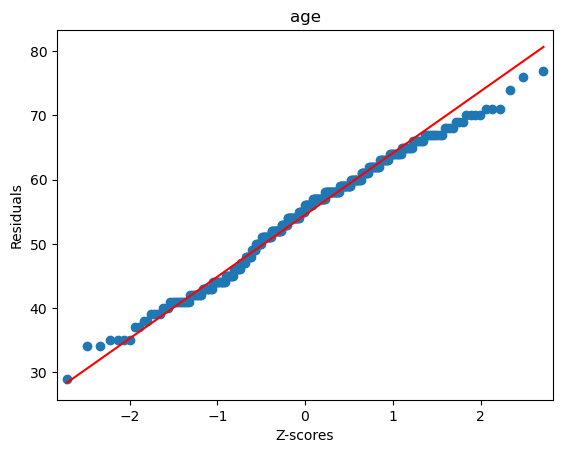

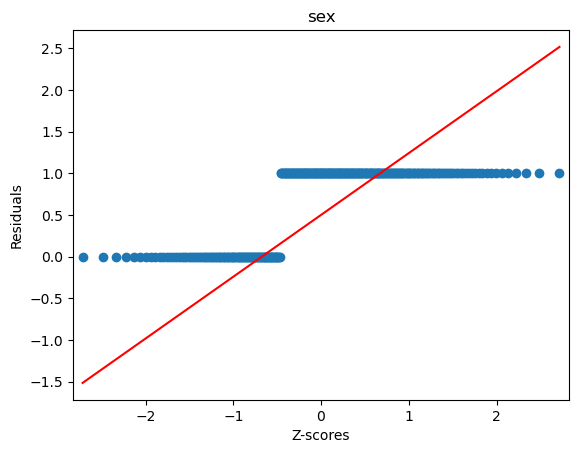

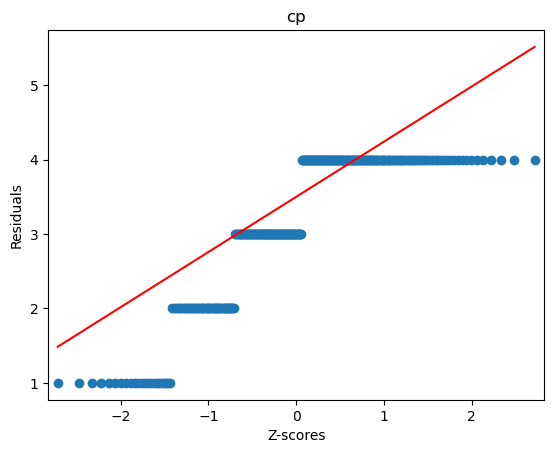

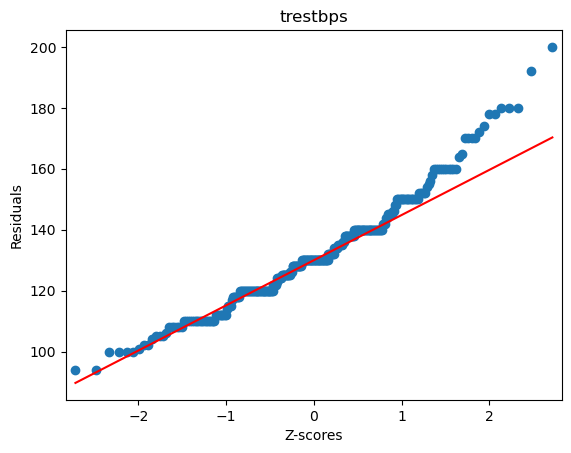

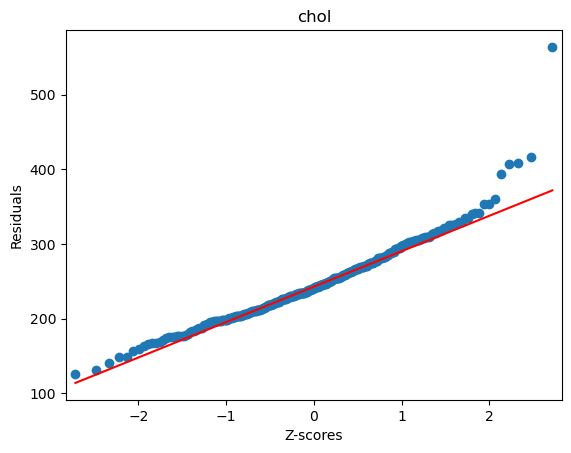

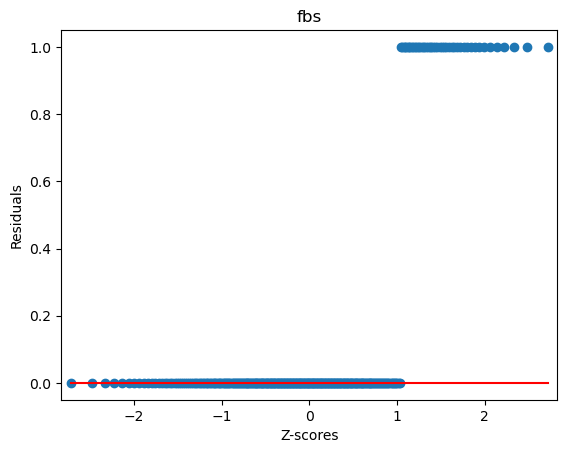

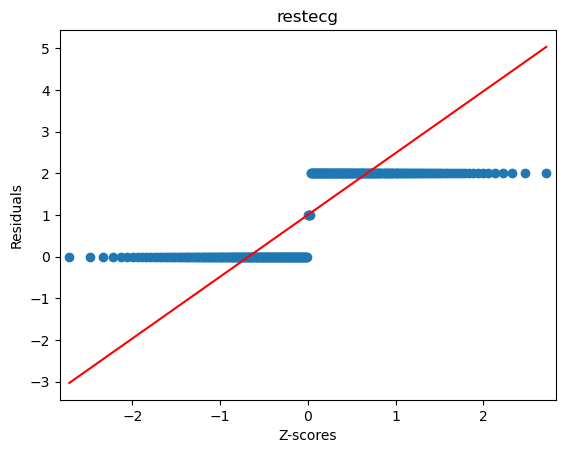

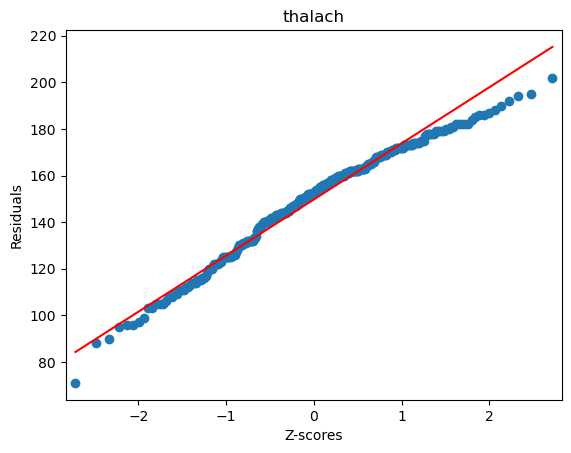

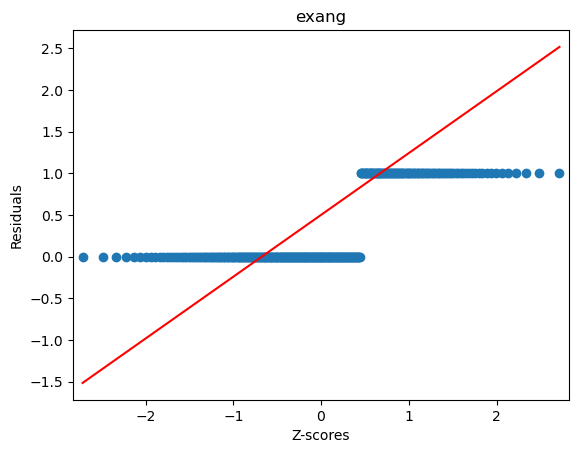

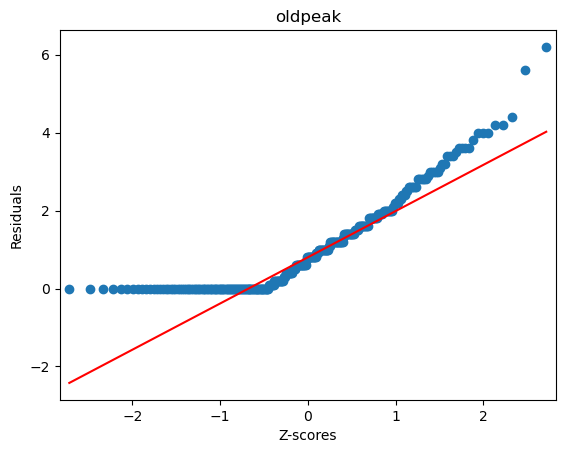

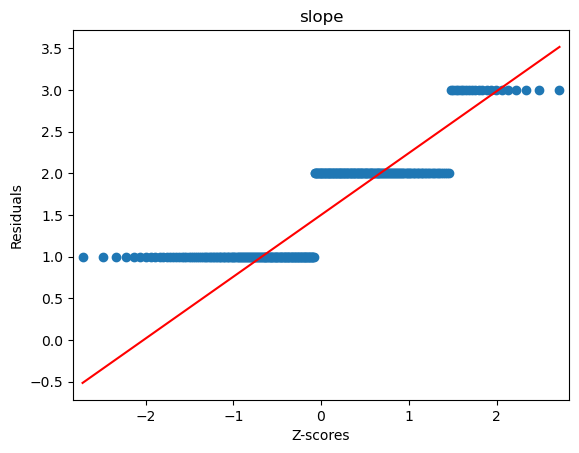

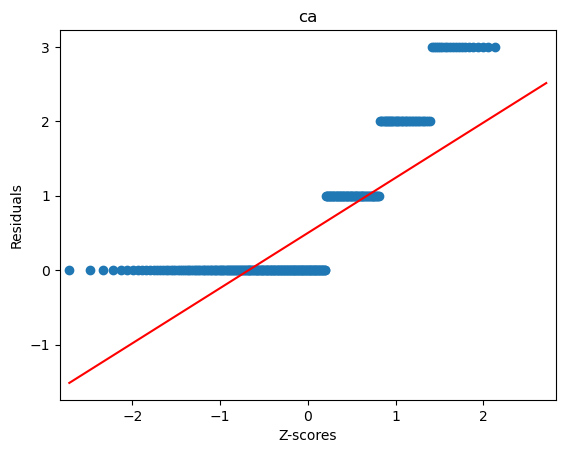

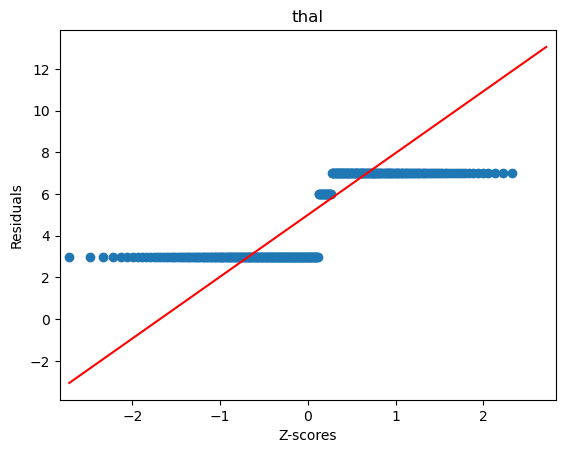

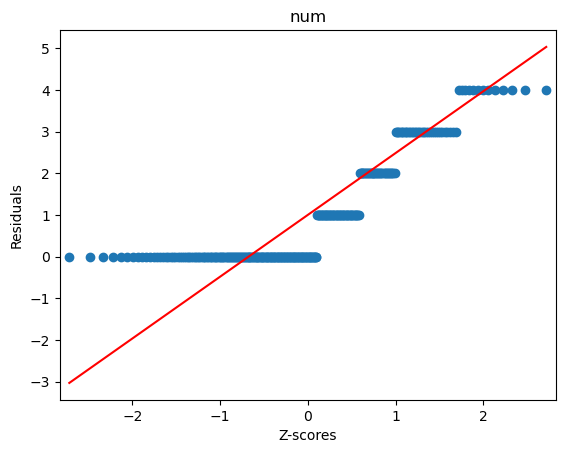

In [30]:
for col in df_corrected:
    qqPlot(df_corrected[col], col)